# Name: **OBBA MARK CALVIN**
# RegNO: **S23B23\047**
# AccessNo: **B24277**

# Part One: CIFAR-10 Image Classification using a Convolutional Neural Network











## Task 1: Data preparation

load CIFAR-10, **normalize** pixel values to a stable scale for training, split the official 50k training images into **training** and **validation** sets, and keep the official **10k test** set untouched for final evaluation.

### Why data augmentation is useful

CIFAR-10 images are small (32×32) and the training set is finite. **Augmentation** applies label-preserving transforms (e.g. small shifts via crop-after-padding, horizontal flips) so the model sees many plausible variations of each image. This **reduces overfitting**, improves **generalization** on the test set, and makes the classifier more robust to position and left–right orientation of objects—without collecting new labeled data.

In [ ]:
# Importing all the necessary Libraies and frameworks
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
)



In [ ]:
# Loading the dataset
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()



In [ ]:
# (b) Normalize pixel values to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0



In [ ]:
# (c) Split: training | validation | test (test = official CIFAR-10 test set)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=SEED,
)

print("Training:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)
print("Classes:", len(CLASS_NAMES))

Training: (40000, 32, 32, 3) (40000,)
Validation: (10000, 32, 32, 3) (10000,)
Test: (10000, 32, 32, 3) (10000,)
Classes: 10


### (d) Augmentation — code in the **next cell**

The exam asks you to **perform** augmentation in Task 1. The **next code cell** defines it explicitly as a Keras `Sequential` model named `data_augmentation`. In **Task 2**, `build_cnn()` attaches that same block to the input so every training step sees random transforms; on validation/test, these layers use **deterministic inference** behavior (no random flips/crops).

- **Random crop after padding** — `ZeroPadding2D(4)` then `RandomCrop(32, 32)` (standard CIFAR-10 shift jitter).
- **Horizontal flip** — left–right mirror for orientation invariance.
- **Small rotation (optional)** — `RandomRotation(0.08)` for slight viewpoint change.

This is the same pipeline referenced again as a **training strategy** in Task 3.

In [ ]:
# data augmentation pipeline (used again as the CNN stem in Task 2)
data_augmentation = keras.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        layers.ZeroPadding2D(4, name="pad_for_crop"),
        layers.RandomCrop(32, 32, name="random_crop"),
        layers.RandomFlip("horizontal", name="hflip"),
        layers.RandomRotation(0.08, name="small_rotation"),
    ],
    name="data_augmentation",
)

print("Augmentation pipeline (Task 1d):")
data_augmentation.summary()

Augmentation pipeline (Task 1d):


Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pad_for_crop (ZeroPadding2D)    │ (None, 40, 40, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_crop (RandomCrop)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hflip (RandomFlip)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ small_rotation (RandomRotation) │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

\## Task 2: CNN model design

### Why this architecture?

CIFAR-10 is low resolution but **spatial structure** matters. The network starts with **`data_augmentation`** from Task 1 (pad → crop → flip → rotation) then a **deep stack of convolutional blocks** learns hierarchical features (edges → textures → object parts). **Batch normalization** stabilizes optimization and allows slightly higher learning rates. **Max pooling** downsamples spatial maps and adds translation tolerance. **Dropout** regularizes fully connected layers. **Global average pooling (GAP)** reduces parameters versus a large flatten + dense layer, lowering overfitting risk. **Softmax** on the last layer gives a proper probability vector over 10 classes.

### Role of each layer type

| Component | Purpose |
|-----------|--------|
| **Conv2D** | Local feature extraction with shared weights across space |
| **ReLU** | Non-linearity; enables learning of complex boundaries |
| **BatchNormalization** | Normalize activations per mini-batch; smoother training |
| **MaxPooling2D** | Spatial downsampling; wider receptive field, fewer parameters |
| **Dropout** | Randomly drop units during training to reduce co-adaptation |
| **GlobalAveragePooling2D** | One activation per channel; compact representation before classification |
| **Dense + softmax** | Linear mixing into class logits → probabilities |

In [ ]:
# CNN model design
NUM_CLASSES = 10
INPUT_SHAPE = (32, 32, 3)


def build_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    """CNN with required components: Conv, activation, pooling, BN, dropout, GAP, softmax."""
    inputs = keras.Input(shape=input_shape, name="image")

    # Task 1 (d): same `data_augmentation` Sequential as defined above
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(64, 3, padding="same", name="conv1a")(x)
    x = layers.BatchNormalization(name="bn1a")(x)
    x = layers.Activation("relu", name="relu1a")(x)
    x = layers.Conv2D(64, 3, padding="same", name="conv1b")(x)
    x = layers.BatchNormalization(name="bn1b")(x)
    x = layers.Activation("relu", name="relu1b")(x)
    x = layers.MaxPooling2D(2, name="pool1")(x)
    x = layers.Dropout(0.2, name="drop1")(x)

    # Block 2
    x = layers.Conv2D(128, 3, padding="same", name="conv2a")(x)
    x = layers.BatchNormalization(name="bn2a")(x)
    x = layers.Activation("relu", name="relu2a")(x)
    x = layers.Conv2D(128, 3, padding="same", name="conv2b")(x)
    x = layers.BatchNormalization(name="bn2b")(x)
    x = layers.Activation("relu", name="relu2b")(x)
    x = layers.MaxPooling2D(2, name="pool2")(x)
    x = layers.Dropout(0.3, name="drop2")(x)

    # Block 3
    x = layers.Conv2D(256, 3, padding="same", name="conv3a")(x)
    x = layers.BatchNormalization(name="bn3a")(x)
    x = layers.Activation("relu", name="relu3a")(x)
    x = layers.Conv2D(256, 3, padding="same", name="conv3b")(x)
    x = layers.BatchNormalization(name="bn3b")(x)
    x = layers.Activation("relu", name="relu3b")(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.4, name="drop_head")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)
    return keras.Model(inputs, outputs, name="cifar10_cnn")


model = build_cnn()
model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1a (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1a (BatchNormalization)       │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1a (Activation)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1b (BatchNormalization)       │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1b (Activation)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2a (BatchNormalization)       │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2a (Activation)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2b (BatchNormalization)       │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2b (Activation)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3a (BatchNormalization)       │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3a (Activation)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3b (BatchNormalization)       │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3b (Activation)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             

 Total params: 1,151,562 (4.39 MB)

 Trainable params: 1,149,770 (4.39 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Task 3: Model training

### Training parameters

| Setting | Value | Rationale |
|--------|--------|-----------|
| **Optimizer** | AdamW (fallback: Adam) | **AdamW** decouples weight decay from gradient updates; code uses Adam if your TF build has no `AdamW`. |
| **Learning rate** | `1e-3` initial | Standard starting point; adjusted by schedule below. |
| **Weight decay** | `1e-4` | Mild L2-style regularization on weights (via AdamW). |
| **Batch size** | `128` | Good GPU utilization and stable batch statistics for BatchNorm. |
| **Epochs** | up to `80` (with early stopping) | Enough capacity to converge; early stopping prevents wasted epochs. |
| **Loss** | `sparse_categorical_crossentropy` | Matches integer labels (0–9). |

### Training strategies (and justification)

1. **Learning rate scheduling (`ReduceLROnPlateau`)** — When validation loss stalls, reducing the LR helps fine-tune weights and often improves final accuracy without manual tuning.
2. **Weight decay (AdamW)** — Penalizes large weights to improve generalization; especially useful with a fairly deep CNN on CIFAR-10.
3. **Early stopping** — Monitors `val_loss` and stops when improvement stops, **restoring the best weights**. This limits **overfitting** and saves time.
4. **Data augmentation** — Defined in Task 1 as `data_augmentation` and wired into the CNN in Task 2; acts as **regularization** during training.

**What we did not add (and why):** extras like mixup/cutout or cosine decay are optional; the rubric asks for clear justification—the above set already covers scheduling, decay, early stopping, and augmentation without obscuring the core exam requirements.

In [ ]:
# Model Training
BATCH_SIZE = 128
EPOCHS = 80
INITIAL_LR = 1e-3
WEIGHT_DECAY = 1e-4
 
model = build_cnn()

if hasattr(keras.optimizers, "AdamW"):
    optimizer = keras.optimizers.AdamW(
        learning_rate=INITIAL_LR, weight_decay=WEIGHT_DECAY
    )
else:
    optimizer = keras.optimizers.Adam(learning_rate=INITIAL_LR)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

# Accuracies with restored best weights (after early stopping)
train_loss, train_acc_best = model.evaluate(x_train, y_train, verbose=0)
val_loss, val_acc_best = model.evaluate(x_val, y_val, verbose=0)
print(f"Training accuracy (best weights): {train_acc_best:.4f}")
print(f"Validation accuracy (best weights): {val_acc_best:.4f}")

Epoch 1/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.4059 - loss: 1.6096 - val_accuracy: 0.1503 - val_loss: 3.4265 - learning_rate: 0.0010
Epoch 2/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.5510 - loss: 1.2472 - val_accuracy: 0.4544 - val_loss: 1.4463 - learning_rate: 0.0010
Epoch 3/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.6120 - loss: 1.0966 - val_accuracy: 0.6183 - val_loss: 1.0801 - learning_rate: 0.0010
Epoch 4/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.6420 - loss: 1.0091 - val_accuracy: 0.6595 - val_loss: 0.9789 - learning_rate: 0.0010
Epoch 5/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.6718 - loss: 0.9320 - val_accuracy: 0.5769 - val_loss: 1.1791 - learning_rate: 0.0010
Epoch 6/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.6959 - loss: 0.8752 - val_accuracy: 0.6969 - val_loss: 0.8939 - learning_rate: 0.0010
Epoch 7/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.7129 - l

## Task 4: Model evaluation

I report **training and validation** metrics from `history` then **test** accuracy with **precision, recall, and F1** (macro-averaged and per-class). Plots include **accuracy / loss curves**, a **confusion matrix**, and **sample predictions**.

### Discussion: overfitting / underfitting

- If **training accuracy ≫ validation accuracy** (and validation loss rises while training loss falls), the model is **overfitting**. Mitigations already in use: dropout, weight decay, augmentation, early stopping.
- If **both** training and validation accuracy are **low**, the model may be **underfitting** (capacity too small, LR too low, or not enough epochs).
- **Per-class** precision/recall (and the confusion matrix) show **which categories** are confused (e.g. cat vs dog), which is typical on CIFAR-10 given image size.

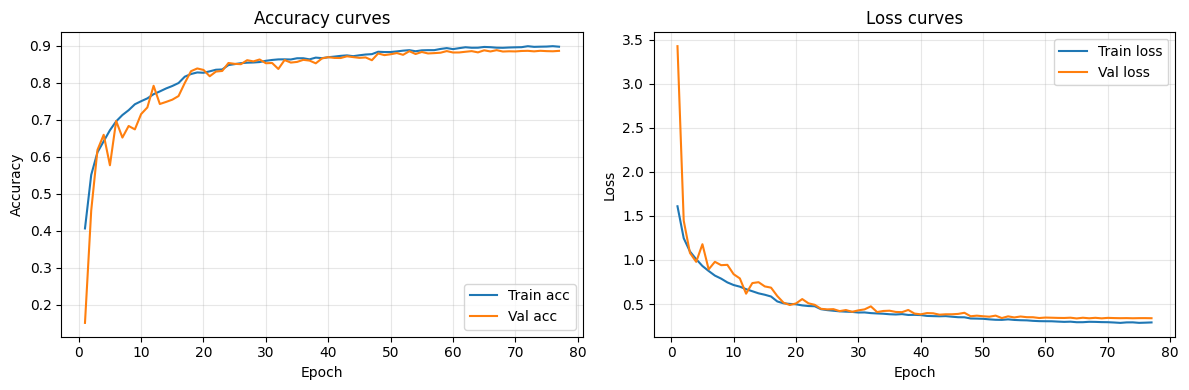

Final training accuracy (last epoch): 0.8979
Final validation accuracy (last epoch): 0.8866


In [ ]:
hist = history.history
epochs_ran = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_ran, hist["accuracy"], label="Train acc")
axes[0].plot(epochs_ran, hist["val_accuracy"], label="Val acc")
axes[0].set_title("Accuracy curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, hist["loss"], label="Train loss")
axes[1].plot(epochs_ran, hist["val_loss"], label="Val loss")
axes[1].set_title("Loss curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

train_acc_final = hist["accuracy"][-1]
val_acc_final = hist["val_accuracy"][-1]
print(f"Final training accuracy (last epoch): {train_acc_final:.4f}")
print(f"Final validation accuracy (last epoch): {val_acc_final:.4f}")

In [ ]:
y_proba = model.predict(x_test, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(y_proba, axis=1)

test_acc = accuracy_score(y_test, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test precision (macro): {prec_macro:.4f}")
print(f"Test recall (macro): {rec_macro:.4f}")
print(f"Test F1 score (macro): {f1_macro:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
Test accuracy: 0.8858
Test precision (macro): 0.8860
Test recall (macro): 0.8858
Test F1 score (macro): 0.8854

              precision    recall  f1-score   support

    airplane     0.8490    0.9220    0.8840      1000
  automobile     0.9387    0.9500    0.9443      1000
        bird     0.8265    0.8620    0.8439      1000
         cat     0.8261    0.7600    0.7917      1000
        deer     0.8779    0.8700    0.8739      1000
         dog     0.8573    0.8110    0.8335      1000
        frog     0.8837    0.9420    0.9119      1000
       horse     0.9273    0.9050    0.9160      1000
        ship     0.9468    0.9250    0.9358      1000
       truck     0.9268    0.9110    0.9188      1000

    accuracy                         0.8858     10000
   macro avg     0.8860    0.8858    0.8854     10000
weighted avg     0.8860    0.8858    0.8854     10000



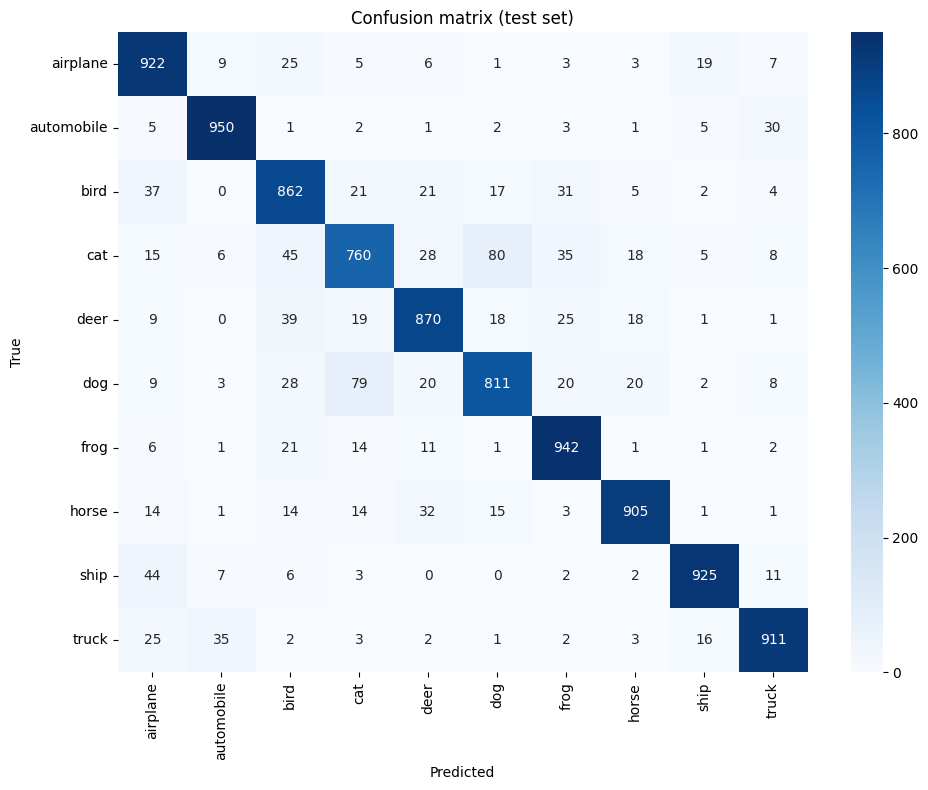

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

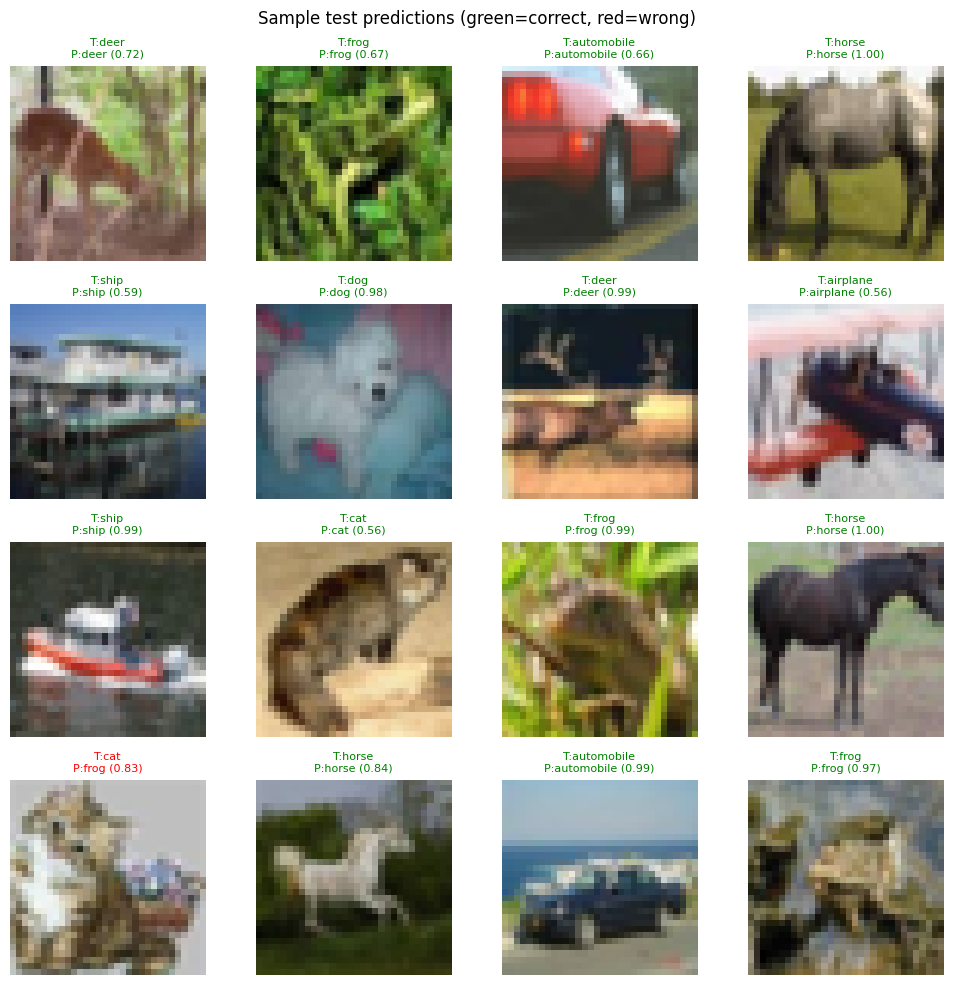

In [ ]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(x_test), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()
for ax, i in zip(axes, idx):
    img = x_test[i]
    true_c = CLASS_NAMES[y_test[i]]
    pred_c = CLASS_NAMES[y_pred[i]]
    conf = float(y_proba[i].max())
    ax.imshow(img)
    ax.axis("off")
    color = "green" if y_pred[i] == y_test[i] else "red"
    ax.set_title(f"T:{true_c}\nP:{pred_c} ({conf:.2f})", fontsize=8, color=color)
plt.suptitle("Sample test predictions (green=correct, red=wrong)", fontsize=12)
plt.tight_layout()
plt.show()

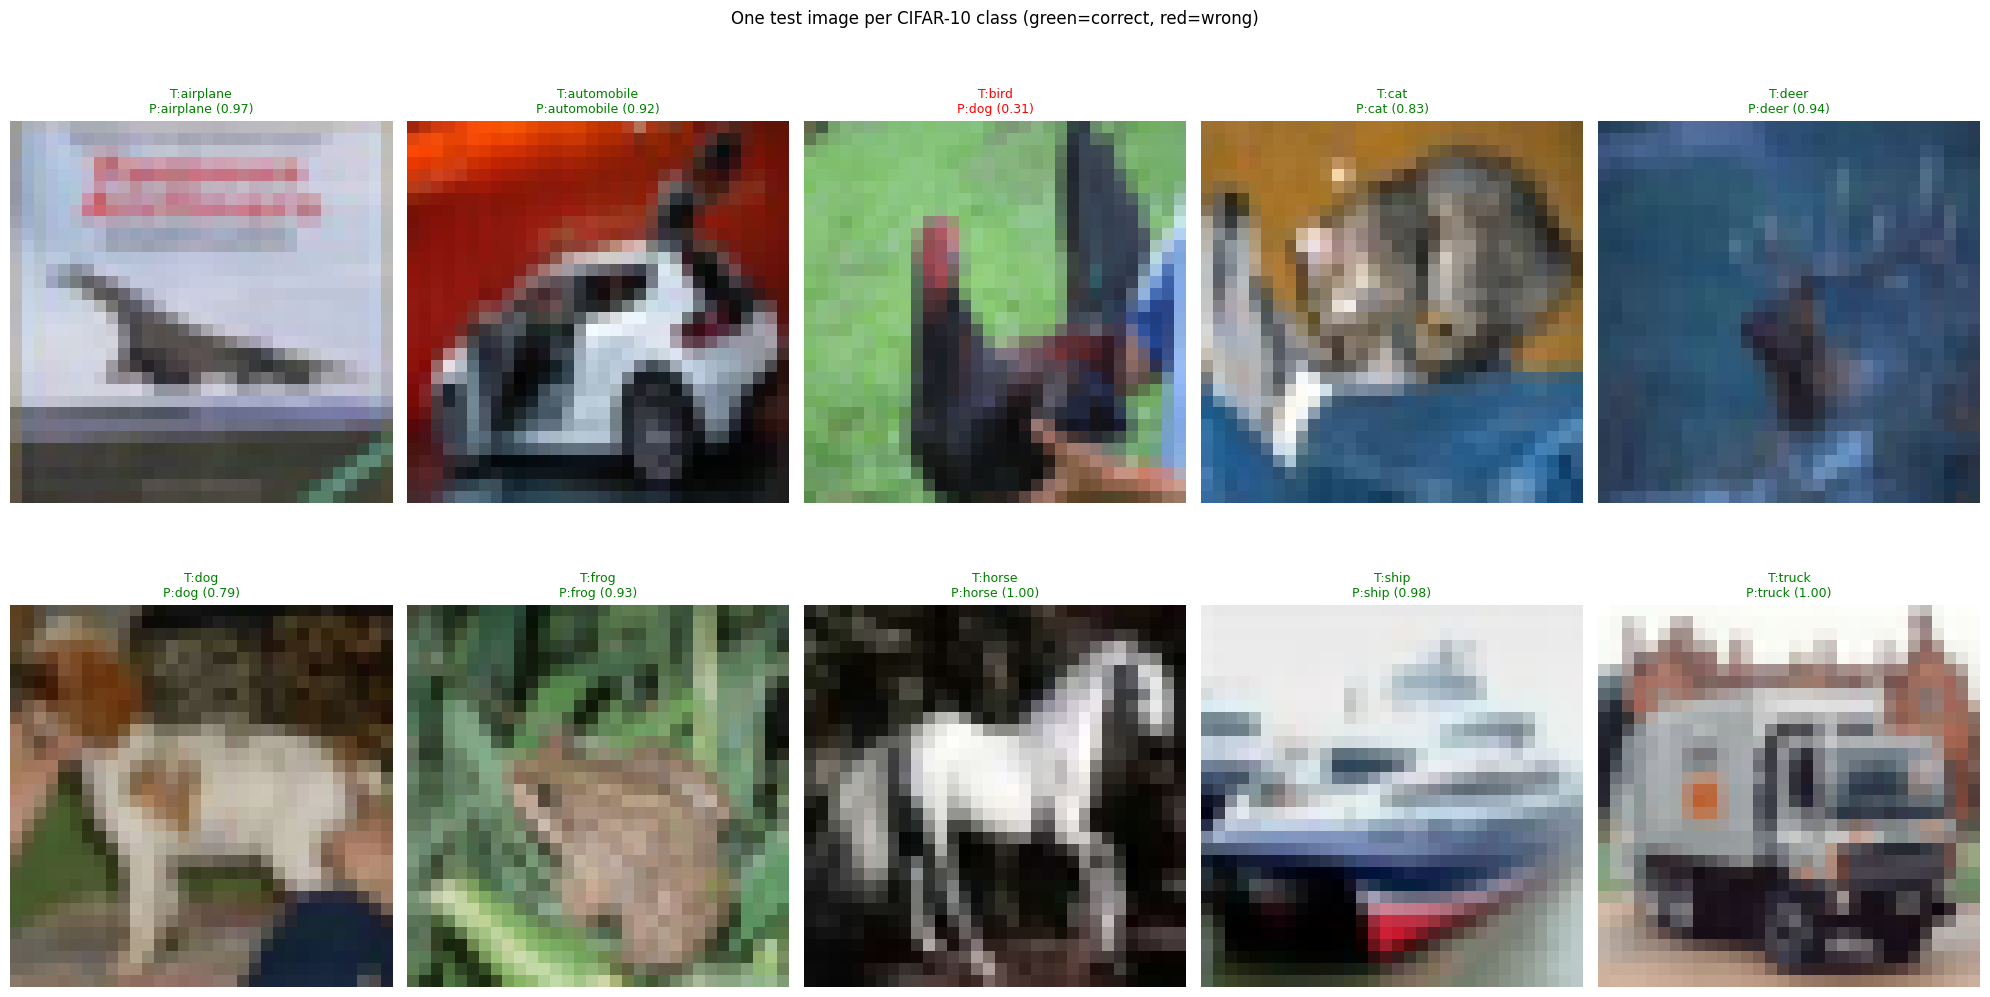

In [ ]:
# Show one deterministic test example per class (airplane ... truck)
indices_per_class = []
for class_id in range(len(CLASS_NAMES)):
    class_indices = np.where(y_test == class_id)[0]
        # Pick the first occurrence for reproducible visualization
    indices_per_class.append(class_indices[0])

fig, axes = plt.subplots(2, 5, figsize=(20, 11))
axes = axes.flatten()
for ax, i in zip(axes, indices_per_class):
    img = x_test[i]
    true_c = CLASS_NAMES[y_test[i]]
    pred_c = CLASS_NAMES[y_pred[i]]
    conf = float(y_proba[i].max())
    ax.imshow(img)
    ax.axis("off")
    color = "green" if y_pred[i] == y_test[i] else "red"
    ax.set_title(f"T:{true_c}\nP:{pred_c} ({conf:.2f})", fontsize=9, color=color)

plt.suptitle("One test image per CIFAR-10 class (green=correct, red=wrong)", fontsize=12)
plt.tight_layout()
plt.show()

---
### End of Part One

Run all cells top to bottom. **Part Two** (report and slides) reuses the figures and numbers from this notebook.

**Optional:** save the trained model with `model.save("cifar10_model.keras")` after training if you need to reload later.